https://huggingface.co/docs/transformers/model_doc/bert

In [3]:
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import torch
from torch.utils.data import DataLoader
torch.cuda.is_available()

True

In [5]:
print(torch.cuda.device_count())
print(torch.cuda.current_device())

1
0


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
torch.cuda.empty_cache()
print(torch.cuda.memory_summary(device=None, abbreviated=False))

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

In [8]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset

/home/arman/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, attn_implementation="eager")
model.to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2866.12it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [10]:
inputs = tokenizer("rubbish", return_tensors="pt").to(device)
outputs = model(**inputs)
pred = torch.argmax(outputs.logits, dim=1).item()
pred


0

In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [12]:
dataset = load_dataset("imdb")

In [13]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [14]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [15]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})

In [16]:
train_loader = DataLoader(dataset["train"], batch_size=64, shuffle=True)
test_loader = DataLoader(dataset["test"], batch_size=64)

In [17]:
def train_model_iter():
    model.train()

    for batch in train_loader:
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["label"].to(device)
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

    print("epoch finished")

In [18]:
def count_accuracy() -> float:
    model.eval()

    correct = 0
    total = 0

    batch_count = 0

    with torch.no_grad():
        for batch in test_loader:
            batch_count += 1
            if batch_count  % 20 == 0:
                print("batch", batch_count)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy

In [19]:
start_time = time.monotonic()
for epoch in range(3):
    train_model_iter()
    print("end epoch", epoch, time.monotonic() - start_time)
    accuracy = count_accuracy()
    print("get accuracy on epoch", epoch, time.monotonic() - start_time, "===", accuracy)

epoch finished
end epoch 0 268.32268991800004
batch 20
batch 40
batch 60
batch 80
batch 100
batch 120
batch 140
batch 160
batch 180
batch 200
batch 220
batch 240
batch 260
batch 280
batch 300
batch 320
batch 340
batch 360
batch 380
get accuracy on epoch 0 381.139575678 === 0.8686
epoch finished
end epoch 1 655.2868467779999
batch 20
batch 40
batch 60
batch 80
batch 100
batch 120
batch 140
batch 160
batch 180
batch 200
batch 220
batch 240
batch 260
batch 280
batch 300
batch 320
batch 340
batch 360
batch 380
get accuracy on epoch 1 769.068786844 === 0.873
epoch finished
end epoch 2 1043.867548578
batch 20
batch 40
batch 60
batch 80
batch 100
batch 120
batch 140
batch 160
batch 180
batch 200
batch 220
batch 240
batch 260
batch 280
batch 300
batch 320
batch 340
batch 360
batch 380
get accuracy on epoch 2 1157.761419336 === 0.87336


In [20]:
inputs = tokenizer(
    "very bad film",
    return_tensors="pt"
).to(device)

outputs = model(**inputs, output_attentions=True)

logits = outputs.logits
attentions = outputs.attentions
pred = torch.argmax(logits, dim=1).item()
pred

0

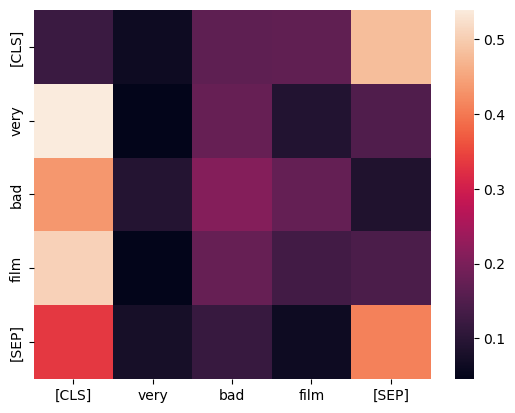

In [24]:
att = attentions[0][0][0].detach().cpu().numpy()

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

sns.heatmap(att, xticklabels=tokens, yticklabels=tokens)
plt.show()